In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler, Session
from qiskit import QuantumCircuit, transpile, generate_preset_pass_manager

from qiskit.circuit.library import QAOAAnsatz
import time, pandas as pd

your_api_key = "V_5F6RZPUb9GB37hSH3CQrQpdFX7WpfP2kek91zjo0Ml"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5e194ca79679454da57a2ad2d3e49a9d:749f65fa-d77a-44f6-913a-5a77858ae7aa::"


QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=your_api_key,
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/5e194ca79679454da57a2ad2d3e49a9d:749f65fa-d77a-44f6-913a-5a77858ae7aa::",
    overwrite=True
)
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")  # get the backend object, not string

# Example: simple QAOA circuit (2 qubits, p=1)
#qc = QAOAAnsatz(cost_operator=QuantumCircuit(2), reps=1)
# qc = QAOAAnsatz(cost_operator=QuantumCircuit(2), reps=1)
# qc.measure_all()

# execution_times = []
# timestamps = []

# n_iterations = 12  # run one every 5 minutes for 1 hour

# for i in range(n_iterations):
#     t0 = time.time()
#     tqc = transpile(qc, backend=backend)
#     pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
#     qc_isa = pm.run(qc)
#     t1 = time.time()

#     timestamps.append(time.strftime("%Y-%m-%d %H:%M:%S"))
#     execution_times.append(t1 - t0)

#     print(f"Iteration {i}: Execution time = {t1 - t0:.2f} s")

#     if i < n_iterations - 1:
#         time.sleep(5*60)

# exec_df = pd.DataFrame({
#     "timestamp": pd.to_datetime(timestamps),
#     "execution_time_sec": execution_times
# })
# exec_df.to_csv("qaoa_execution_times.csv", index=False)

In [25]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.circuit.library import QFT
from qiskit import transpile
import time

# --- IBM Runtime setup ---
your_api_key = "V_5F6RZPUb9GB37hSH3CQrQpdFX7WpfP2kek91zjo0Ml"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5e194ca79679454da57a2ad2d3e49a9d:749f65fa-d77a-44f6-913a-5a77858ae7aa::"

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=your_api_key,
    instance=your_crn,
    overwrite=True
)

service = QiskitRuntimeService()
backend = service.backend("ibm_brisbane")

# --- QFT configuration ---
n_qubits = 112
shots = 1024  # single-shot execution

# --- Build QFT circuit and decompose to remove parameters ---
qc = QFT(num_qubits=n_qubits, do_swaps=True).decompose()
qc.measure_all()

# --- Transpile circuit for backend ---
qc_transpiled = transpile(qc, backend=backend, optimization_level=3)

# --- Run via SamplerV2 ---
sampler = Sampler(mode=backend)

print("Submitting transpiled QFT circuit to backend...")
t0 = time.time()
job = sampler.run([qc_transpiled], shots=shots)  # wrapped in list
result = job.result()
t1 = time.time()

elapsed = t1 - t0
print(f"\n✅ Total elapsed time (submission → result): {elapsed:.2f} seconds")
print(f"Job ID: {job.job_id()}")
print(result)
# Print measurement counts

# get the first (and only) result
pub_result = result[0]

# Convert measured bits to counts
counts = pub_result.data.meas.get_counts()
print(counts)



Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 11.68 seconds
Job ID: d4186n98mjus73cbl7i0
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=112>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': {'__type__': 'ExecutionSpans', '__value__': {'spans': [DoubleSliceSpan(<start='2025-10-29 21:13:06', stop='2025-10-29 21:13:09', size=1024>)]}}}, 'version': 2})
{'1011101010111001101111000110110101100100001111000000100100010001011110001011100011000101100011010010011010010110': 1, '1110111010111001111010001010000001110010010010010000011010000110101000110100100010011001001111011100101100111110': 1, '0010011111111111001110000000110101100010001101100000011010000110110010000010101011011000101110101010010110011011': 1, '0111011011001001011011001111110001100010111001100101001001010001110101011110100010000100110110010010000000001111': 1, '1010101111100011111101000000110110000010

In [ ]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session
from qiskit import transpile
import time
import itertools
from qiskit.quantum_info import SparsePauliOp

n = 112  # number of qubits (increase this)
terms = []
for i, j in itertools.combinations(range(n), 2):
    term = ["I"] * n
    term[i] = term[j] = "Z"
    terms.append("".join(term))
coeffs = [1.0] * len(terms)
H = SparsePauliOp(terms, coeffs)

# --- simple Hamiltonian for demonstration ---
# H = SparsePauliOp(["ZZ", "ZI", "IZ"], coeffs=[1.0, 1.0, 1.0])
qaoa = QAOAAnsatz(cost_operator=H, reps=1)
qaoa.measure_all()

# check parameters
print("Parameters:", qaoa.ordered_parameters)

# must match the number of parameters
param_values = [[0.5] * len(qaoa.parameters)]  # match all parameters

# transpile
qc_transpiled = transpile(qaoa, backend=backend)

sampler = Sampler(mode=backend)

print("Submitting transpiled QAOA circuit to backend...")
t0 = time.time()
job = sampler.run([(qc_transpiled, param_values)], shots=shots)
result = job.result()
t1 = time.time()

elapsed = t1 - t0
print(f"\n✅ Total elapsed time (submission → result): {elapsed:.2f} seconds")
print(f"Job ID: {job.job_id()}")
print(result)
# Print measurement counts

# get the first (and only) result
pub_result = result[0]

# Convert measured bits to counts
counts = pub_result.data.meas.get_counts()
print(counts)

Parameters: [ParameterVectorElement(t[0]), ParameterVectorElement(t[1])]
Submitting transpiled QAOA circuit to backend...

✅ Total elapsed time (submission → result): 25.14 seconds
Job ID: d41d0u4h4j8s73egdv50
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(1,), num_shots=1024, num_bits=112>), shape=(1,)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': {'__type__': 'ExecutionSpans', '__value__': {'spans': [DoubleSliceSpan(<start='2025-10-30 02:42:12', stop='2025-10-30 02:42:17', size=1024>)]}}}, 'version': 2})
{'0100010001110111000010100011101011010110101110001010100101001110100010011100111001011100011001011110101100011101': 1, '1010110000101100011000011000001111000110101001011010000101000100100010110001110010000101101010100010110110011100': 1, '0111000000110101001000011010101110011100000001010010000101000001010001111010100000000111101011111100011010011011': 1, '00001100010000101101001010001011111110111011101100111100011011110100010

In [11]:
from qiskit import QuantumCircuit
import random
shots = 1024  # single-shot execution


def random_circuit_fixed_depth_2q(n_qubits, depth, num_two_qubit):
    qc = QuantumCircuit(n_qubits)
    layers = [[] for _ in range(depth)]

    # ---- Step 1: randomly assign 2-qubit gates to layers ----
    for _ in range(num_two_qubit):
        layer = random.randint(0, depth - 1)
        q1, q2 = random.sample(range(n_qubits), 2)
        layers[layer].append(("cx", q1, q2))

    # ---- Step 2: fill remaining slots with 1-qubit gates ----
    one_qubit_gates = ["rx", "ry", "rz"]
    for d in range(depth):
        used_qubits = set()
        # Mark qubits used by 2-qubit gates in this layer
        for gate in layers[d]:
            _, q1, q2 = gate
            used_qubits.add(q1)
            used_qubits.add(q2)
        # Add random 1-qubit gates to unused qubits
        for q in range(n_qubits):
            if q not in used_qubits:
                g = random.choice(one_qubit_gates)
                θ = random.random() * 3.14159
                layers[d].append((g, q, θ))

    # ---- Step 3: Build circuit in order ----
    for d in range(depth):
        for gate in layers[d]:
            if gate[0] == "cx":
                _, q1, q2 = gate
                qc.cx(q1, q2)
            else:
                g, q, θ = gate
                getattr(qc, g)(θ, q)

    return qc

for _ in range(100):
# Example usage:
    qc = random_circuit_fixed_depth_2q(
        n_qubits=6,
        depth=10,
        num_two_qubit=15
    )

    qc.measure_all()

    # --- Transpile circuit for backend ---
    qc_transpiled = transpile(qc, backend=backend, optimization_level=3)

    # --- Run via SamplerV2 ---
    sampler = Sampler(mode=backend)

    print("Submitting transpiled QFT circuit to backend...")
    t0 = time.time()
    job = sampler.run([qc_transpiled], shots=shots)  # wrapped in list
    result = job.result()
    t1 = time.time()

    elapsed = t1 - t0
    print(f"\n✅ Total elapsed time (submission → result): {elapsed:.2f} seconds")
    # print(f"Job ID: {job.job_id()}")
    # print(result)
    # # Print measurement counts

    # # get the first (and only) result
    # pub_result = result[0]

    # # Convert measured bits to counts
    # counts = pub_result.data.meas.get_counts()
    # print(counts)



Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 7.83 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 7.49 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 7.55 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 6.68 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 12.72 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 6.18 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 6.39 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 10.83 seconds
Submitting transpiled QFT circuit to backend...

✅ Total elapsed time (submission → result): 10.98 seconds
Submitting transpiled QFT circuit to backen

RequestsApiError: 'HTTPSConnectionPool(host=\'us-east.quantum-computing.cloud.ibm.com\', port=443): Max retries exceeded with url: /jobs/d4eble4cdebc73euuan0?exclude_params=true (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x000001FD1477D5D0>: Failed to resolve \'us-east.quantum-computing.cloud.ibm.com\' ([Errno 11001] getaddrinfo failed)"))'

In [10]:
from qiskit import QuantumCircuit
import random
shots = 1024  # single-shot execution


def random_circuit_fixed_depth_2q(n_qubits, depth, num_two_qubit):
    qc = QuantumCircuit(n_qubits)
    layers = [[] for _ in range(depth)]

    # ---- Step 1: randomly assign 2-qubit gates to layers ----
    for _ in range(num_two_qubit):
        layer = random.randint(0, depth - 1)
        q1, q2 = random.sample(range(n_qubits), 2)
        layers[layer].append(("cx", q1, q2))

    # ---- Step 2: fill remaining slots with 1-qubit gates ----
    one_qubit_gates = ["rx", "ry", "rz"]
    for d in range(depth):
        used_qubits = set()
        # Mark qubits used by 2-qubit gates in this layer
        for gate in layers[d]:
            _, q1, q2 = gate
            used_qubits.add(q1)
            used_qubits.add(q2)
        # Add random 1-qubit gates to unused qubits
        for q in range(n_qubits):
            if q not in used_qubits:
                g = random.choice(one_qubit_gates)
                θ = random.random() * 3.14159
                layers[d].append((g, q, θ))

    # ---- Step 3: Build circuit in order ----
    for d in range(depth):
        for gate in layers[d]:
            if gate[0] == "cx":
                _, q1, q2 = gate
                qc.cx(q1, q2)
            else:
                g, q, θ = gate
                getattr(qc, g)(θ, q)

    return qc

for _ in range(5):
# Example usage:
    qc = random_circuit_fixed_depth_2q(
        n_qubits=6,
        depth=5,
        num_two_qubit=5
    )
    print(qc)

      ┌────────────┐┌────────────┐┌───────────┐  ┌────────────┐┌─────────────┐»
q_0: ─┤ Rz(2.8926) ├┤ Ry(2.6362) ├┤ Rz(2.145) ├──┤ Ry(1.0442) ├┤ Rx(0.49661) ├»
      └───┬───┬────┘├────────────┤├───────────┴┐┌┴────────────┤└─────────────┘»
q_1: ─────┤ X ├─────┤ Rz(1.5614) ├┤ Rz(2.0151) ├┤ Ry(0.29948) ├───────────────»
          └─┬─┘     ├────────────┤├────────────┤└────┬───┬────┘               »
q_2: ───────■───────┤ Rx(1.0017) ├┤ Rx(2.5741) ├─────┤ X ├────────────────────»
      ┌────────────┐├────────────┤└────────────┘     └─┬─┘      ┌───────────┐ »
q_3: ─┤ Ry(3.0959) ├┤ Rx(2.2356) ├──────■──────────────■────────┤ Ry(1.224) ├─»
     ┌┴────────────┤├────────────┤      │        ┌────────────┐ ├───────────┴┐»
q_4: ┤ Rz(0.20205) ├┤ Rx(2.5601) ├──────┼────────┤ Rx(2.2804) ├─┤ Ry(2.3873) ├»
     ├─────────────┤├────────────┤    ┌─┴─┐      ├────────────┤ └────────────┘»
q_5: ┤ Rz(0.54554) ├┤ Ry(2.9209) ├────┤ X ├──────┤ Rx(1.4179) ├───────────────»
     └─────────────┘└────────────┘    └─

             WorkloadId     Status  \
0  d4efabh2bisc73a1euu0  completed   
1  d4efaah2bisc73a1eusg  completed   
2  d4efa98lslhc73cul3e0  completed   
3  d4efa7ulo8as739nju10  completed   
4  d4efa6glslhc73cul3b0  completed   

                                            Instance   Region Mode  \
0  crn:v1:bluemix:public:quantum-computing:us-eas...  us-east  job   
1  crn:v1:bluemix:public:quantum-computing:us-eas...  us-east  job   
2  crn:v1:bluemix:public:quantum-computing:us-eas...  us-east  job   
3  crn:v1:bluemix:public:quantum-computing:us-eas...  us-east  job   
4  crn:v1:bluemix:public:quantum-computing:us-eas...  us-east  job   

                    Created                 Completed      QPU  \
0  2025-11-18T22:37:34.956Z  2025-11-18T22:37:38.916Z  ibm_fez   
1  2025-11-18T22:37:30.392Z  2025-11-18T22:37:34.441Z  ibm_fez   
2  2025-11-18T22:37:25.489Z  2025-11-18T22:37:30.038Z  ibm_fez   
3  2025-11-18T22:37:19.736Z  2025-11-18T22:37:25.059Z  ibm_fez   
4  2025-11-18T22:37:

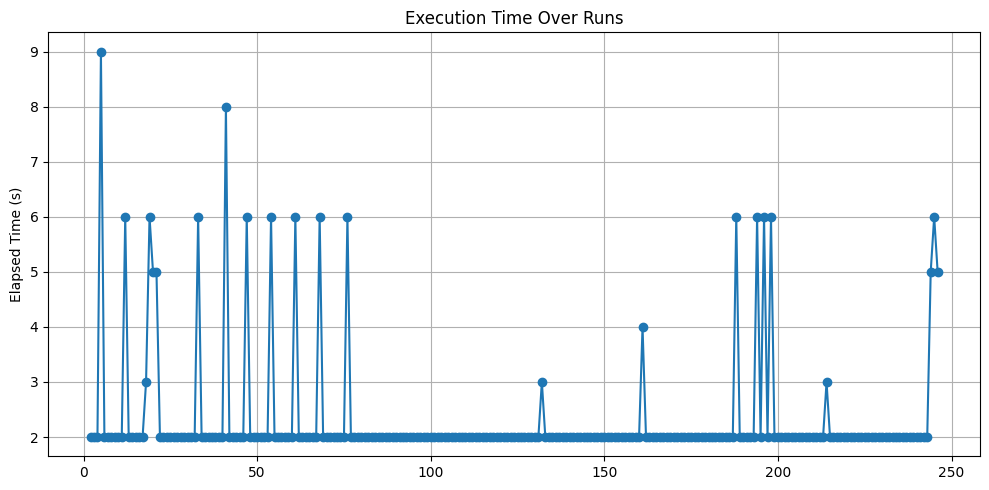

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load CSV ---
df = pd.read_csv("all_time_workloads.csv")
subset = df.iloc[2:247]
# --- Preview data ---
print(df.head())

# --- Plot (example: time vs elapsed_time) ---
plt.figure(figsize=(10,5))
plt.plot(subset["Usage (seconds)"], marker="o")
plt.ylabel("Elapsed Time (s)")
plt.title("Execution Time Over Runs")
plt.grid(True)
plt.tight_layout()
plt.show()
